# Performance Animation (2010–Today)

In this notebook, we create an animated chart that shows the **normalized performance** of a selected stock (**TICKER**) and the **S&P 500** over time.

This allows us to:
- Visually track relative performance
- See turning points and trend divergences
- Compare long-term growth dynamics


In [1]:
from src.technical_setup import *

c:\Users\Linus\Desktop\Python\src\technical_setup.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock = yf.download(TICKER, start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed
c:\Users\Linus\Desktop\Python\src\technical_setup.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start=START_DATE)["Close"]
[*********************100%***********************]  1 of 1 completed


## Load and Normalize Data

We download historical closing prices for both assets and normalize them to 0% at the start date.


In [2]:
# --- Load data ---
df1 = yf.download(["^GSPC", TICKER], start="2010-01-01")["Close"].dropna()

# Normalize performance to 0% at the start
norm_sp500 = (df1["^GSPC"] / df1["^GSPC"].iloc[0] - 1) * 100
norm_stock = (df1[TICKER] / df1[TICKER].iloc[0] - 1) * 100


C:\Users\Linus\AppData\Local\Temp\ipykernel_19484\3709478840.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df1 = yf.download(["^GSPC", TICKER], start="2010-01-01")["Close"].dropna()
[*********************100%***********************]  2 of 2 completed


## Function: Animate Performance Comparison

This function creates an animated line chart showing the normalized performance of two assets over time.


In [3]:
def animate_performance(df, series1, series2, label1="S&P 500", label2="Stock",
                         step=20, frame_interval=0.05,
                         title="Performance Animation (2010–Today)",
                         save_path=None):
    """
    Animates normalized performance of two assets over time.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing the datetime index.
    series1 : pd.Series
        First normalized performance series.
    series2 : pd.Series
        Second normalized performance series.
    label1 : str
        Label for the first asset.
    label2 : str
        Label for the second asset.
    step : int, optional
        Number of points to skip between frames (controls animation speed).
    frame_interval : float, optional
        Pause duration between frames in seconds.
    title : str
        Plot title.
    save_path : str, optional
        Path to save the animation (e.g., 'figures/animation.mp4'). If None, animation is not saved.
    """
    fig, ax = plt.subplots(figsize=(15, 8))
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Date")
    ax.set_ylabel("Performance (%)")
    ax.set_xlim(df.index[0], df.index[-1])
    ax.set_ylim(min(series1.min(), series2.min()) - 5, max(series1.max(), series2.max()) + 5)

    line1, = ax.plot([], [], color="blue", label=label1)
    line2, = ax.plot([], [], color="red", label=label2)
    ax.legend()

    # Animate
    for i in range(0, len(df), step):
        line1.set_data(df.index[:i], series1.values[:i])
        line2.set_data(df.index[:i], series2.values[:i])

        clear_output(wait=True)
        display(fig)
        plt.pause(frame_interval)

    plt.show()

    # Optional: save static final frame
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        fig.savefig(save_path, dpi=150, bbox_inches="tight")


## Example Usage

We animate the normalized performance of the stock and the S&P 500.


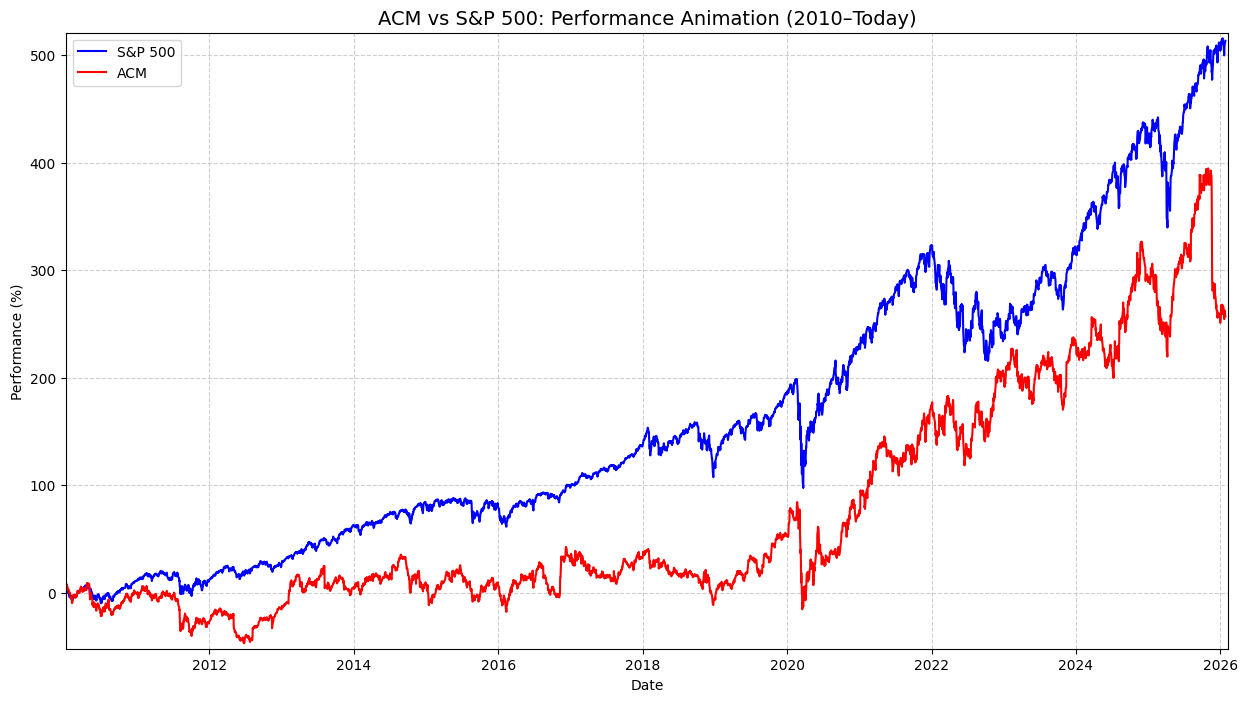

In [4]:
animate_performance(
    df=df1,
    series1=norm_sp500,
    series2=norm_stock,
    label1="S&P 500",
    label2=TICKER,
    step=20,
    frame_interval=0.05,
    title=f"{TICKER} vs S&P 500: Performance Animation (2010–Today)",
    save_path=f"figures/{TICKER}_performance_animation_final_frame.png"
)
